<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [2]:
# Your code here
from bs4 import BeautifulSoup # this module helps in web scrapping.
import requests  # this module helps us to download a web page
import pandas as pd

Download the webpage at the url


In [3]:
#your code goes here
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"
data  = requests.get(url).text # get the contents of the webpage in text format and store in a variable called data

Create a soup object


In [4]:
#your code goes here
soup = BeautifulSoup(data,"html.parser")  # create a soup object using the variable 'data'

Scrape the `Language name` and `annual average salary`.


In [5]:
#your code goes here
table = soup.find('table') #find a html table in the web page. In html, table is represented by the tag <table>
#Get all rows from the table
for row in table.find_all('tr'): # in html table row is represented by the tag <tr>
    # Get all columns in each row.
    cols = row.find_all('td') # in html a column is represented by the tag <td>
    Language_name = cols[1].getText() 
    annual_average_salary = cols[3].getText() 
    print(Language_name, ',', annual_average_salary)

Language , Average Annual Salary
Python , $114,383
Java , $101,013
R , $92,037
Javascript , $110,981
Swift , $130,801
C++ , $113,865
C# , $88,726
PHP , $84,727
SQL , $84,793
Go , $94,082


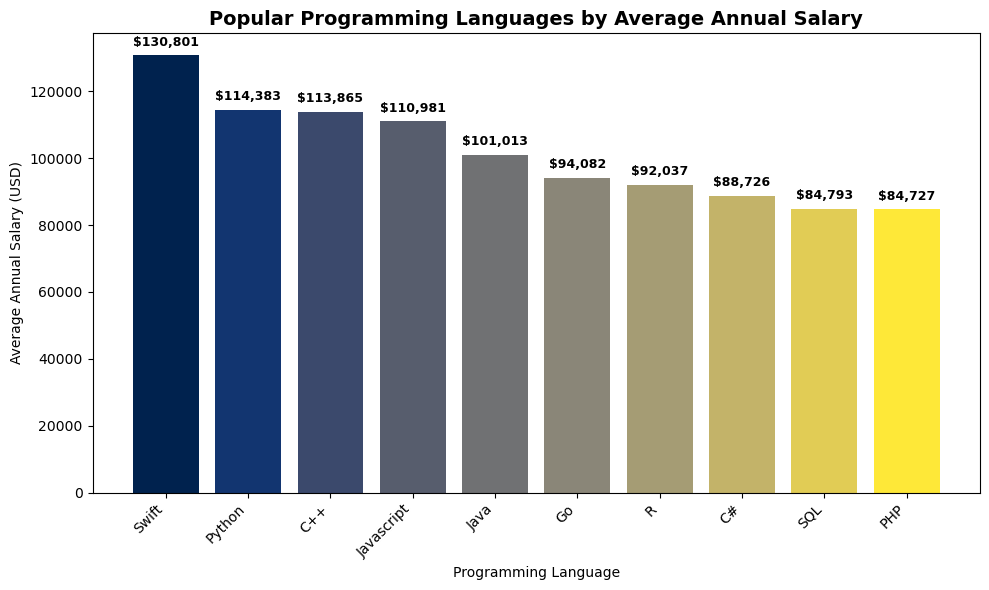

In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# STEP 1: URL to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

# STEP 2: Scrape and parse HTML
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table")

# STEP 3: Extract headers and rows
headers = [th.text.strip() for th in table.find("tr").find_all(["th", "td"])]
rows = []
for tr in table.find_all("tr")[1:]:
    cols = [td.text.strip() for td in tr.find_all("td")]
    rows.append(cols)

df = pd.DataFrame(rows, columns=headers)

# STEP 4: Clean salary column
df["Average Annual Salary"] = df["Average Annual Salary"].replace('[\$,]', '', regex=True).astype(float)

# STEP 5: Sort data
df_sorted = df.sort_values(by="Average Annual Salary", ascending=False)

# STEP 6: Create chart
plt.figure(figsize=(10, 6))
colors = plt.cm.cividis(np.linspace(0, 1, len(df_sorted)))
bars = plt.bar(df_sorted["Language"], df_sorted["Average Annual Salary"], color=colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2000, f"${int(height):,}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Popular Programming Languages by Average Annual Salary", fontsize=14, weight='bold')
plt.xlabel("Programming Language")
plt.ylabel("Average Annual Salary (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# STEP 7: Save chart
plt.savefig("popular_languages_salary_chart.png", dpi=300)
plt.show()

Save the scrapped data into a file named *popular-languages.csv*


In [12]:
# your code goes here
import pandas as pd
scrape = (Language_name, ',', annual_average_salary)
scraped_df = pd.DataFrame(scrape)
scraped_df.to_csv('popular-languages.csv')

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
